# Avance 1: Generación o selección del set de datos y preprocesado
### Emilio Leví Díaz Abarde

### 24 de mayo de 2026

En el siguiente notebook (creado en Google Colab), se podrá observar el proceso de exportación de datos de un dataset de imágenes proveniente de kaggle, la utilización de archivos CSV para entrenar un modelo ML de clasificación, aumentar la cantidad de imágenes por medio de modificaciones para incrementar la precisión del modelo, y preprocesamiento.

En este caso, se está utilizando un dataset que clasifica mariposas.

In [16]:
import kagglehub
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Descargar dataset de Butterfly Image Classification
En este bloque se descarga el dataset desde Kaggle.

Cable aclarar que el dataset ya está separado en train y test, contando con directorios diferentes correspondientes a cada uno de los conjuntos. Se importa directamente desde kaggle; cuenta con archivos JPG de las imágenes de las mariposas.

Además, tiene dos archivos de tipo CSV; uno de entrenamiento y uno de pruebas. El CSV de entrenamiento contiene el nombre del archivo y el tipo de mariposa que es. A partir de ahí, se entrena al modelo.

In [17]:
# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'butterfly-image-classification' dataset.
Path to dataset files: /kaggle/input/butterfly-image-classification


In [18]:
import os

print(os.listdir(path + '/test'))

['Image_747.jpg', 'Image_561.jpg', 'Image_345.jpg', 'Image_2566.jpg', 'Image_1593.jpg', 'Image_844.jpg', 'Image_1975.jpg', 'Image_270.jpg', 'Image_526.jpg', 'Image_968.jpg', 'Image_2104.jpg', 'Image_1769.jpg', 'Image_2008.jpg', 'Image_2013.jpg', 'Image_322.jpg', 'Image_2526.jpg', 'Image_860.jpg', 'Image_2078.jpg', 'Image_2105.jpg', 'Image_2534.jpg', 'Image_1103.jpg', 'Image_2165.jpg', 'Image_2088.jpg', 'Image_1576.jpg', 'Image_574.jpg', 'Image_879.jpg', 'Image_22.jpg', 'Image_1808.jpg', 'Image_2394.jpg', 'Image_1168.jpg', 'Image_2426.jpg', 'Image_2323.jpg', 'Image_2538.jpg', 'Image_486.jpg', 'Image_1340.jpg', 'Image_1400.jpg', 'Image_608.jpg', 'Image_994.jpg', 'Image_1185.jpg', 'Image_943.jpg', 'Image_592.jpg', 'Image_2002.jpg', 'Image_2292.jpg', 'Image_1963.jpg', 'Image_352.jpg', 'Image_1860.jpg', 'Image_1585.jpg', 'Image_1621.jpg', 'Image_2439.jpg', 'Image_1890.jpg', 'Image_1075.jpg', 'Image_1969.jpg', 'Image_687.jpg', 'Image_1335.jpg', 'Image_2392.jpg', 'Image_1610.jpg', 'Image_1677

### Obtener información desde el CSV de Training_set.csv

El dataset contiene un CSV llamado Training_set.csv donde viene el nombre del archivo junto con la clasificación de la mariposa. Se utilizarán estos datos para entrenar al modelo.

In [19]:
train_csv = pd.read_csv(path + "/Training_set.csv")
test_csv = pd.read_csv(path + "/Testing_set.csv")

train_csv.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [20]:
train_csv["filepath"] = train_csv["filename"].apply(

    lambda x: os.path.join(path, "train", x)

)

test_csv["filepath"] = test_csv["filename"].apply(

    lambda x: os.path.join(path, "test", x)

)

### Llevar a cabo la augmentation
En esta sección, se lleva a cabo la aumentación de datos. Se utiliza el comando ImageDataGenerator importado de tensorflow, y se generan las imágenes nuevas a partir del mismo.

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

# Se generan las imágenes con los parámetros de modificación especificados
train_datagen = ImageDataGenerator(
    rescale = 1./255, # convierte los valores de los pixeles a un número entre 0-1
    rotation_range = 10, # rango de grados para rotar la imagen
    width_shift_range = 0.2, # rango de porcentaje para incrementar el ancho
    height_shift_range = 0.2, # rango de porcentaje para incrementar la altura
    shear_range = 0.3, # rango de % aplicar transformaciones de deformación
    zoom_range = 0.3, # rango de % para aplicar transformaciones de zoom
    horizontal_flip = True # habilitar cambiar la orientación de la imagen
)

In [22]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_csv,
    x_col="filepath", # path del archivo
    y_col="label",
    target_size = (150, 150),
    batch_size = 8,
    class_mode='categorical' # ya que son múltiples categorías
  )

images, labels = train_generator[0]

# Se obtiene el objeto de los índicies de las clases
# a partir de lo que se generó en train_generator
class_indices = train_generator.class_indices


Found 6499 validated image filenames belonging to 75 classes.


### Visualización
Se imprimen las imágenes generadas para la aumentación junto con el tipo de mariposa que son.

<Figure size 640x480 with 0 Axes>

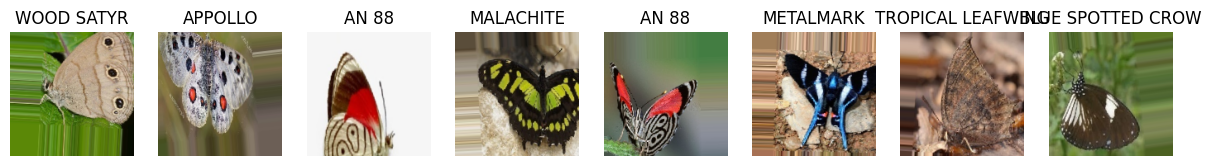

<Figure size 640x480 with 0 Axes>

In [23]:
# Se voltea el orden del diccionario class_indices para que sea
# índice: valor en lugar de valor: índice
idx_to_class = {v: k for k, v in class_indices.items()}

f, axarr = plt.subplots(1, images.shape[0], figsize=(15, 4))

for i in range(images.shape[0]):
  axarr[i].imshow(images[i])
  class_index = labels[i].argmax()
  class_name = idx_to_class[class_index]
  axarr[i].set_title(class_name) # configurar el nombr de la clase de mariposa
  axarr[i].axis("off")

plt.figure()

### CNN para el modelo de análisis

In [24]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers

num_classes = len(class_indices)

model = models.Sequential()

model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (150,150,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))

# Activación softmax en vez de sigmoid porque existen múltiples clases
model.add(layers.Dense(num_classes,activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 219040)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    56,074,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,094,051 (213.98 MB)

 Trainable params: 56,094,051 (213.98 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo
Se ejecuta el entrenamiento del modelo (en este caso únicamente en una época) y se grafica utilizando matplotlib para generar dos gráficos; uno que muestre la evolución del valor de accuracy y otro que muestra la evolución de loss.

Cuando existen más épocas hay mayor cantidad de puntos que muestran cómo evoluciona el entrenamiento del modelo; si sube el loss o baja, si el accuracy incrementa, etc.

813/813 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - acc: 0.0186 - loss: 4.3383


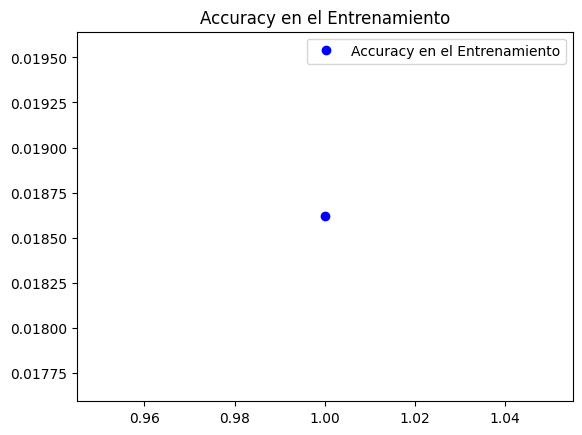

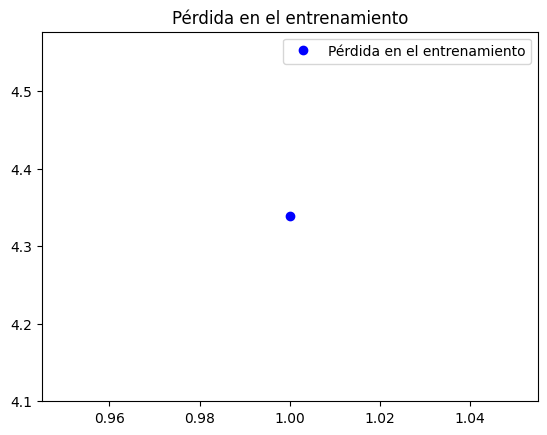

In [25]:
history = model.fit(
						train_generator,
						epochs = 1)


acc = history.history['acc']
loss = history.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='Accuracy en el Entrenamiento')
plt.title('Accuracy en el Entrenamiento')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='Pérdida en el entrenamiento')
plt.title('Pérdida en el entrenamiento')
plt.legend()

plt.show()